# Comparações Não e Sim

In [1]:
from analise_sinal import analiseEspectral

## Análise do sinal

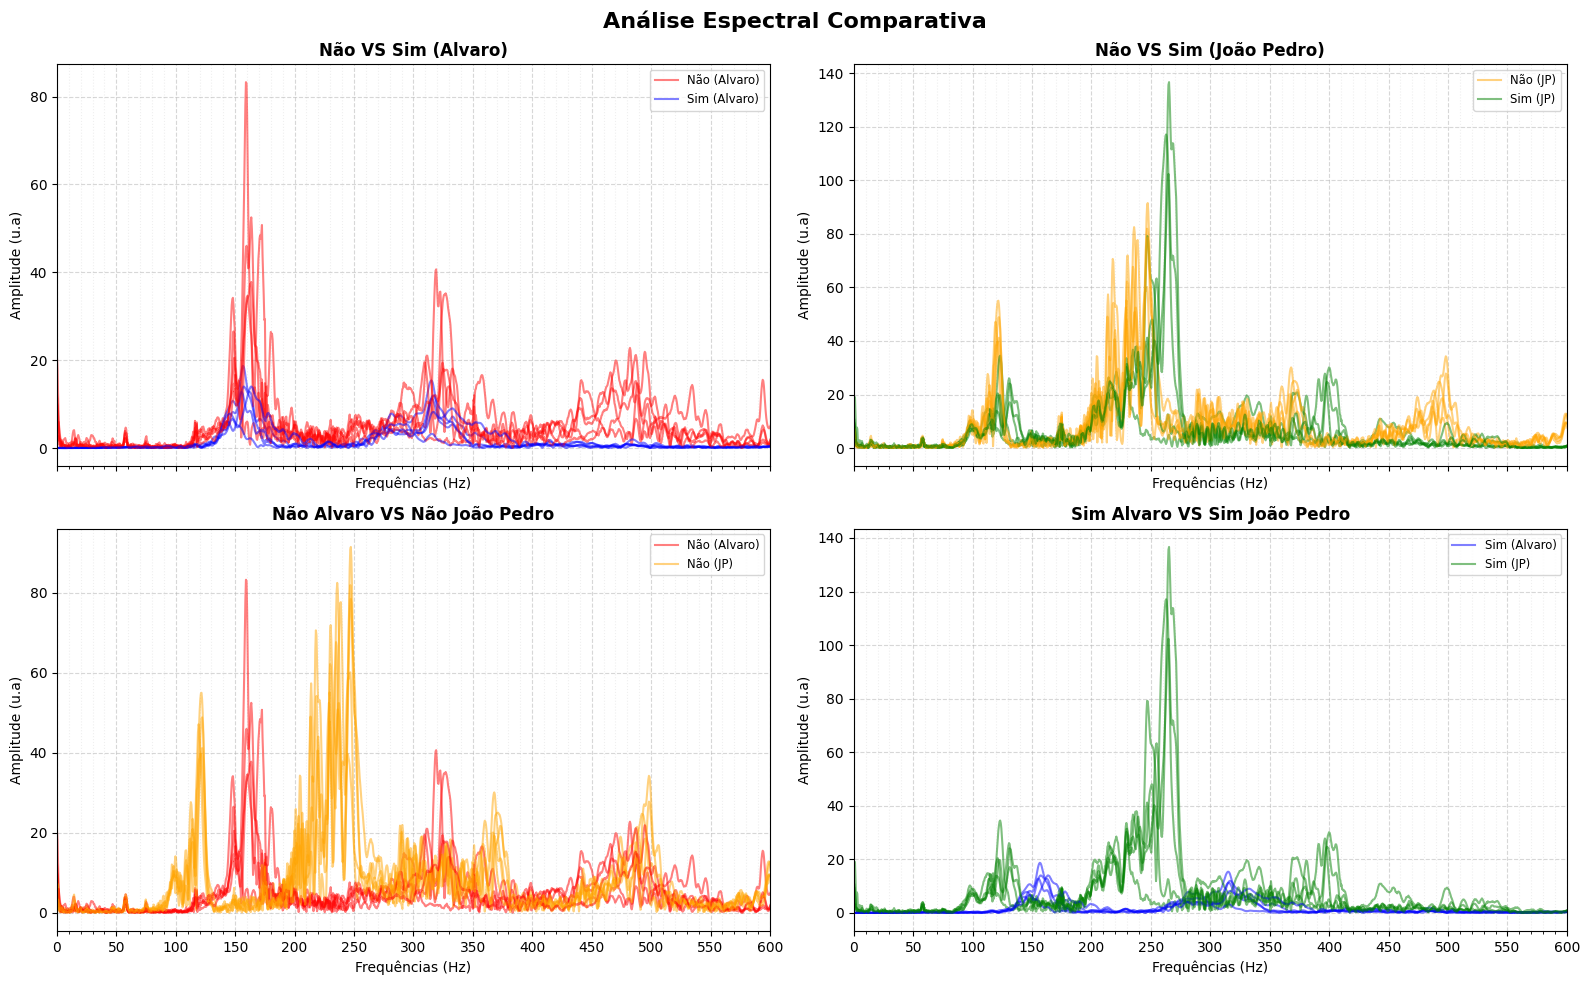

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parâmetros
diretorioArquivo = "audios_cortados"
frequenciadeCorte = 600
amostras = 10

fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

for i in range(1, 6):
    try:
        nome_nao = f"nao_alv_{i}.m4a"
        f_n, amp_n = analiseEspectral.analiseporFourier(diretorioArquivo, nome_nao)
        
        nome_sim = f"sim_alv_{i}.m4a"
        f_s, amp_s = analiseEspectral.analiseporFourier(diretorioArquivo, nome_sim)
        
        jp_nao = f"nao_jp_{i}.m4a"
        f_n_jp, amp_n_jp = analiseEspectral.analiseporFourier(diretorioArquivo, jp_nao)
        
        jp_sim = f"sim_jp_{i}.m4a"
        f_s_jp, amp_s_jp = analiseEspectral.analiseporFourier(diretorioArquivo, jp_sim)
        
        # --- Plotagem nos Subplots Específicos ---
        lbl_cond = (i == 1) 

        # 1. Linha 0, Coluna 0: Não Vs Sim de Alvaro
        axs[0, 0].plot(f_n, amp_n, color='red', alpha=0.5, label="Não (Alvaro)" if lbl_cond else "")
        axs[0, 0].plot(f_s, amp_s, color='blue', alpha=0.5, label="Sim (Alvaro)" if lbl_cond else "")

        # 2. Linha 0, Coluna 1: Não vs Sim Joao Pedro
        axs[0, 1].plot(f_n_jp, amp_n_jp, color='orange', alpha=0.5, label="Não (JP)" if lbl_cond else "")
        axs[0, 1].plot(f_s_jp, amp_s_jp, color='green', alpha=0.5, label="Sim (JP)" if lbl_cond else "")

        # 3. Linha 1, Coluna 0: Nao alvaro Vs Nao Joao Pedro
        axs[1, 0].plot(f_n, amp_n, color='red', alpha=0.5, label="Não (Alvaro)" if lbl_cond else "")
        axs[1, 0].plot(f_n_jp, amp_n_jp, color='orange', alpha=0.5, label="Não (JP)" if lbl_cond else "")

        # 4. Linha 1, Coluna 1: Sim alvaro Vs Sim Joao Pedro
        axs[1, 1].plot(f_s, amp_s, color='blue', alpha=0.5, label="Sim (Alvaro)" if lbl_cond else "")
        axs[1, 1].plot(f_s_jp, amp_s_jp, color='green', alpha=0.5, label="Sim (JP)" if lbl_cond else "")

    except Exception as e:
        print(f"Erro no índice {i}: {e}")


titulos = [
    ["Não VS Sim (Alvaro)", "Não VS Sim (João Pedro)"],
    ["Não Alvaro VS Não João Pedro", "Sim Alvaro VS Sim João Pedro"]
]


for row in range(2):
    for col in range(2):
        ax = axs[row, col]
        
        # 1. Ajustado para começar do 0 Hz até o limite de corte
        ax.set_xlim(0, frequenciadeCorte)
        
        # 2. Define os marcadores principais de 50 em 50 Hz (inteiros e legíveis)
        ax.set_xticks(np.arange(0, frequenciadeCorte + 1, 50))
        
        # 3. Opcional: adiciona pequenos tracinhos de 10 em 10 Hz sem poluir com texto
        ax.set_xticks(np.arange(0, frequenciadeCorte + 1, 10), minor=True)
        
        ax.set_title(titulos[row][col], fontsize=12, fontweight='bold')
        ax.set_xlabel("Frequências (Hz)")
        ax.set_ylabel("Amplitude (u.a)")
        ax.legend(loc='upper right', fontsize='small')
        ax.grid(True, linestyle='--', alpha=0.5) 
        ax.grid(True, which='minor', linestyle=':', alpha=0.2) # Grid suave para os valores menores

fig.suptitle("Análise Espectral Comparativa", fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

## Escolhendo as frequências com base no gráfico:
- Todas as frequências entre 100 e 500 (inteiras)

In [3]:
import numpy as np
import pandas as pd


frequencias_desejadas = np.arange(100, 500)


linhas = []


arquivos = [
    ("nao_alv", 0, 1, 1, 0),
    ("sim_alv", 1, 0, 1, 0),
    ("nao_jp",  0, 1, 0, 1),
    ("sim_jp",  1, 0, 0, 1)
]

for arquivo, sim_lbl, nao_lbl, alv_lbl, jp_lbl in arquivos:

    for i in range(1, 6):

        try:

            nome_arquivo = f"{arquivo}_{i}.m4a"

            # FFT
            frequencias, amplitudes = analiseEspectral.analiseporFourier(
                diretorioArquivo,
                nome_arquivo
            )

            frequencias = np.array(frequencias)
            amplitudes = np.array(amplitudes)

            linha = {}

            # Frequências reais da FFT
            for f in frequencias_desejadas:

                # índice do bin REAL mais próximo
                idx = np.argmin(np.abs(frequencias - f))

                # salva amplitude REAL
                linha[f"{f}Hz"] = amplitudes[idx]

            # Labels
            linha["sim"] = sim_lbl
            linha["nao"] = nao_lbl
            linha["alvaro"] = alv_lbl
            linha["jp"] = jp_lbl

            

            linhas.append(linha)

        except Exception as e:
            print(f"Erro em {nome_arquivo}: {e}")

# Cria DataFrame
df = pd.DataFrame(linhas)

In [9]:
df.to_csv("dados.csv", index = False)

## Normalizando as amplitudes

$$
\bar{x}_i(j)=
\frac{x_i(j)-x_{i,\min}}
{x_{i,\max}-x_{i,\min}}
$$

In [5]:
# Embaralhando os dados
df_embaralhado = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Separando a tabela
X = df_embaralhado.iloc[:, :-4]

y = df_embaralhado.iloc[:, -4:]

In [6]:
# Normalizando
X_normalizado = (X - X.min()) / (X.max() - X.min())

In [7]:
df_normalizado = pd.concat([X_normalizado, y], axis=1)
df_normalizado.to_csv("dataset.csv", index=False)

## Tabela final

In [8]:
df_normalizado

,100Hz,101Hz,102Hz,103Hz,104Hz,105Hz,106Hz,107Hz,108Hz,109Hz,...,494Hz,495Hz,496Hz,497Hz,498Hz,499Hz,sim,nao,alvaro,jp
0,0.042688,0.047043,0.040929,0.026008,0.060621,0.004700,0.019363,0.027420,0.031852,0.060081,...,0.203709,0.226545,0.205272,0.140049,0.085072,0.068905,0,1,1,0
1,0.541976,0.639160,0.590463,0.433431,0.424072,0.451968,0.468724,0.428988,0.283641,0.367342,...,0.137889,0.195334,0.248867,0.264670,0.261320,0.290036,1,0,0,1
2,0.661268,0.863054,0.808278,0.648375,0.571323,0.660701,0.743379,0.750416,0.635785,0.880645,...,0.018359,0.012515,0.024651,0.038050,0.039885,0.033435,1,0,0,1
3,0.037613,0.026202,0.052462,0.024464,0.023228,0.034205,0.033227,0.039887,0.013059,0.014056,...,0.129519,0.122237,0.078817,0.084513,0.118805,0.152292,0,1,1,0
4,0.003079,0.009591,0.013833,0.016232,0.013473,0.011164,0.003815,0.002279,0.000000,0.001956,...,0.000431,0.000978,0.000000,0.000000,0.000000,0.000722,1,0,1,0
5,0.031570,0.045675,0.044942,0.043717,0.047033,0.052207,0.038454,0.022485,0.014665,0.022528,...,0.011620,0.008420,0.005082,0.004024,0.002245,0.000951,1,0,1,0
6,0.522006,0.862410,0.306990,0.461207,0.851105,0.779012,0.213882,1.000000,1.000000,1.000000,...,0.857118,0.793216,0.661805,0.512591,0.398920,0.359500,0,1,0,1
7,0.043960,0.046205,0.003366,0.046487,0.069385,0.042145,0.036023,0.060670,0.053014,0.081058,...,0.782258,0.808832,0.681463,0.548457,0.453781,0.366664,0,1,1,0
8,0.470952,0.641956,0.705097,0.669779,0.608305,0.616531,0.616860,0.507541,0.335992,0.372825,...,0.070733,0.095483,0.096260,0.079568,0.048915,0.019906,1,0,0,1
9,0.539426,0.692376,0.623021,0.482972,0.462363,0.509863,0.568360,0.467504,0.302403,0.364020,...,0.022957,0.035492,0.044468,0.048458,0.052668,0.058522,1,0,0,1
